## Spatial Statistics for CPIS Water Source Attribution

This notebook implements three spatial analyses that test the relationship between CPIS siting and dam locations, going beyond the simple distance metrics that prior work relied on.

**A. Bivariate Cross-K function** - Tests whether CPIS cluster near dams at multiple spatial scales simultaneously, compared to a Complete Spatial Randomness (CSR) envelope. Run for all CPIS and for elevation-feasible CPIS separately to test whether the elevation classification in notebook 4 captures real hydrological signal.

**B. Geographically Weighted Regression (GWR)** - Models the CPIS-dam distance relationship as a spatially varying function of groundwater productivity, aridity, and elevation. Local-coefficient and local-R2 maps reveal where groundwater explains dam-distant CPIS and where neither source explains siting.

**C. Flow path connectivity** - Of the CPIS classified as elevation-feasible in notebook 4, traces D8 flow paths downstream from each CPIS's nearest dam to check whether the dam could plausibly drain toward the CPIS cell. This is an exploratory drainage-network check, not a canal-routing model.

### Imports and configuration

In [17]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import rasterio
from rasterio.transform import rowcol, Affine
from rasterio.enums import Resampling
from scipy.spatial import cKDTree
import warnings
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from Code.utils.utility import load_config, resolve_path
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

config = load_config()

# reproducibility
SEED = 42
rng  = np.random.default_rng(SEED)

# analysis parameters
MAX_GWR_POINTS  = 2000    # subsample for GWR (O(n^2) memory)
MAX_FLOW_POINTS = None    # set to an integer to sample flow tracing; None runs all feasible CPIS
N_SIM           = 99      # CSR envelope simulations for cross-K
T_MAX_M         = 200_000 # max search distance for cross-K (200 km)
N_T             = 40      # number of distance bands
FLOW_MAX_STEPS  = 500     # max D8 steps per CPIS on the coarsened DEM grid
FLOW_CELL_M     = 90.0    # legacy nominal source cell size; flow code derives actual coarsened cell size
DEM_SUBSAMPLE   = 16      # read DEM at coarser resolution for flow direction (saves memory)

CRS = 'EPSG:3857'

### Load data

In [18]:
# CPIS (all arid SSA)
cpis = gpd.read_file(resolve_path(config['SSA_Combined_CPIS_All_shp_path'])).to_crs(CRS)
cpis['cx'] = cpis.geometry.centroid.x
cpis['cy'] = cpis.geometry.centroid.y

# Elevation classification from notebook 4 (optional but recommended).
# Shapefile output may truncate 'accessibility' to 'accessibil'.
ELEV_CLASS_COL = None
try:
    cpis_elev = gpd.read_file(resolve_path(config['CPIS_Elevation_Classified_shp_path'])).to_crs(CRS)
    cpis_elev['cx'] = cpis_elev.geometry.centroid.x
    cpis_elev['cy'] = cpis_elev.geometry.centroid.y
    candidates = ['elev_class', 'accessibility', 'accessibil']
    ELEV_CLASS_COL = next((c for c in candidates if c in cpis_elev.columns), None)
    if ELEV_CLASS_COL is None:
        ELEV_CLASS_COL = next((c for c in cpis_elev.columns if c.lower().startswith('access')), None)
    HAS_ELEVATION = ELEV_CLASS_COL is not None
    if HAS_ELEVATION:
        print(f'Elevation classification column: {ELEV_CLASS_COL}')
        print(cpis_elev[ELEV_CLASS_COL].value_counts(dropna=False).to_dict())
    else:
        print('Elevation classification loaded, but no accessibility/class column was found.')
except Exception as exc:
    HAS_ELEVATION = False
    print(f'Elevation classification not found - run 4_dem_flow_analysis.ipynb first. ({exc})')

# Groundwater productivity from notebook 5 (optional)
try:
    gp_df = pd.read_csv(resolve_path(config['CPIS_GP_Groundwater_csv_path']), index_col=0)
    HAS_GP = True
    print(f'Groundwater productivity: {len(gp_df):,} records')
except Exception:
    HAS_GP = False
    print('Groundwater productivity not found - run 5_groundwater_productivity_overlay.ipynb first. GWR will use aridity + elevation only.')

# GDW dams
dams = gpd.read_file(resolve_path(config['GDW_Arid_SSA_Final_shp_path'])).to_crs(CRS)
dam_pts = np.column_stack([dams.geometry.x, dams.geometry.y])

# SSA boundary - used for study area extent and map backgrounds
ssa_bdry = gpd.read_file(resolve_path(config['SSA_All_by_Country_shp_path'])).to_crs(CRS)
bounds = ssa_bdry.total_bounds  # (minx, miny, maxx, maxy)
# Bounding-box area used as normalisation constant in cross-K.
# CSR envelope uses the same constant, so the qualitative L(t) shape is unaffected.
study_area_m2 = (bounds[2] - bounds[0]) * (bounds[3] - bounds[1])

print(f'\nCPIS: {len(cpis):,}  |  Dams: {len(dams):,}')

Elevation classification column: accessibil
{'infeasible_elevation': 14944, 'feasible': 10460, 'infeasible_distance': 4078}
Groundwater productivity: 29,482 records

CPIS: 29,482  |  Dams: 2,764


### Motivating context: CPIS distance to nearest dam

Before running the formal spatial tests, this cell plots the empirical CDF of CPIS-to-nearest-dam distances against a random baseline (same number of points, placed uniformly across the study bounding box). Departure above the random baseline at short distances would indicate CPIS cluster near dams; a flat or below-baseline curve at short distances motivates the analysis that follows.

Median CPIS-dam distance:  18.7 km
Median random-dam distance: 671.1 km


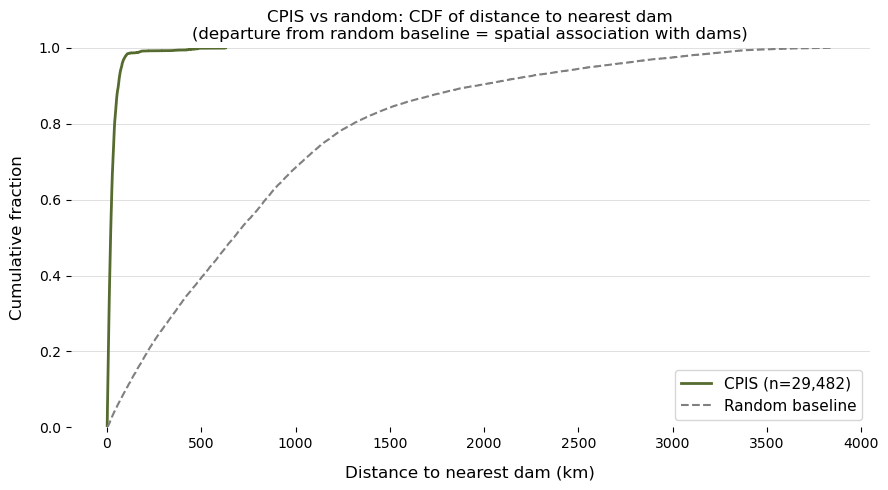

In [19]:
# CPIS-to-nearest-dam distances
cpis_pts_mot = np.column_stack([cpis['cx'].values, cpis['cy'].values])
dist_obs, _ = cKDTree(dam_pts).query(cpis_pts_mot, k=1)
dist_obs_km = dist_obs / 1000

# Random baseline: same number of points placed uniformly in the study bounding box
rand_pts_mot = rng.uniform(
    low =[bounds[0], bounds[1]],
    high=[bounds[2], bounds[3]],
    size=(len(cpis_pts_mot), 2),
)
dist_rand, _ = cKDTree(dam_pts).query(rand_pts_mot, k=1)
dist_rand_km = dist_rand / 1000

fig, ax = plt.subplots(figsize=(9, 5))
ax.ecdf(dist_obs_km,  color='darkolivegreen', lw=2,   label=f'CPIS (n={len(dist_obs_km):,})')
ax.ecdf(dist_rand_km, color='gray',           lw=1.5, ls='--', label='Random baseline')
ax.set_xlabel('Distance to nearest dam (km)', fontsize=12, labelpad=10)
ax.set_ylabel('Cumulative fraction', fontsize=12, labelpad=10)
ax.set_title('CPIS vs random: CDF of distance to nearest dam\n'
             '(departure from random baseline = spatial association with dams)',
             fontsize=12)
ax.legend(fontsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(True, axis='y', lw=0.5, color='lightgray')
ax.grid(False, axis='x')

med_obs  = np.median(dist_obs_km)
med_rand = np.median(dist_rand_km)
print(f'Median CPIS-dam distance:  {med_obs:.1f} km')
print(f'Median random-dam distance: {med_rand:.1f} km')
plt.tight_layout()
plt.show()

### A. Bivariate Cross-K function

The cross-K function K_AB(t) measures the expected number of B-type points (dams) within distance t of a
randomly chosen A-type point (CPIS), normalised by the intensity of B.

$$K_{AB}(t) = \frac{|\text{area}|}{n_A \cdot n_B} \sum_i \sum_j \mathbf{1}[d(A_i, B_j) \leq t]$$

Under complete spatial randomness (independence between CPIS and dams): $E[K_{AB}(t)] = \pi t^2$.

The L-transform $L_{AB}(t) = \sqrt{K_{AB}(t)/\pi} - t$ has expectation 0 under CSR.
Positive values indicate clustering of CPIS around dams at scale t; negative values indicate avoidance.

The 99% CSR envelope is constructed by randomly redistributing dam locations within the study bounding box
across N_SIM simulations.

In [20]:
cpis_pts = np.column_stack([cpis['cx'].values, cpis['cy'].values])
t_values = np.linspace(T_MAX_M / N_T, T_MAX_M, N_T)

tree_cpis = cKDTree(cpis_pts)
tree_dams = cKDTree(dam_pts)

print(f'Computing cross-K ({N_T} bands, 0-{T_MAX_M/1000:.0f} km)...')
counts_obs = tree_cpis.count_neighbors(tree_dams, t_values)
k_obs = counts_obs * study_area_m2 / (len(cpis_pts) * len(dam_pts))
l_obs = np.sqrt(np.maximum(k_obs, 0) / np.pi) - t_values

# Cross-K for elevation-feasible CPIS only
if HAS_ELEVATION:
    feas_mask = cpis_elev[ELEV_CLASS_COL].astype(str).str.lower().eq('feasible')
    feasible_pts = np.column_stack([
        cpis_elev.loc[feas_mask, 'cx'].values,
        cpis_elev.loc[feas_mask, 'cy'].values,
    ])
    counts_feas = cKDTree(feasible_pts).count_neighbors(tree_dams, t_values)
    k_feas = counts_feas * study_area_m2 / (len(feasible_pts) * len(dam_pts))
    l_feas = np.sqrt(np.maximum(k_feas, 0) / np.pi) - t_values
    print(f'Feasible CPIS for cross-K: {len(feasible_pts):,}')

# CSR envelope: randomly redistribute dam locations within study bounding box
print(f'Computing CSR envelope ({N_SIM} simulations)...')
l_sims = np.zeros((N_SIM, N_T))
for s in range(N_SIM):
    rand_pts = rng.uniform(
        low =[bounds[0], bounds[1]],
        high=[bounds[2], bounds[3]],
        size=(len(dam_pts), 2),
    )
    cnt = tree_cpis.count_neighbors(cKDTree(rand_pts), t_values)
    k_s = cnt * study_area_m2 / (len(cpis_pts) * len(dam_pts))
    l_sims[s] = np.sqrt(np.maximum(k_s, 0) / np.pi) - t_values
    if (s + 1) % 25 == 0:
        print(f'  {s + 1}/{N_SIM}')

l_lo = np.percentile(l_sims, 2.5,  axis=0)
l_hi = np.percentile(l_sims, 97.5, axis=0)
print('Done.')

Computing cross-K (40 bands, 0-200 km)...
Feasible CPIS for cross-K: 10,460
Computing CSR envelope (99 simulations)...
  25/99
  50/99
  75/99
Done.


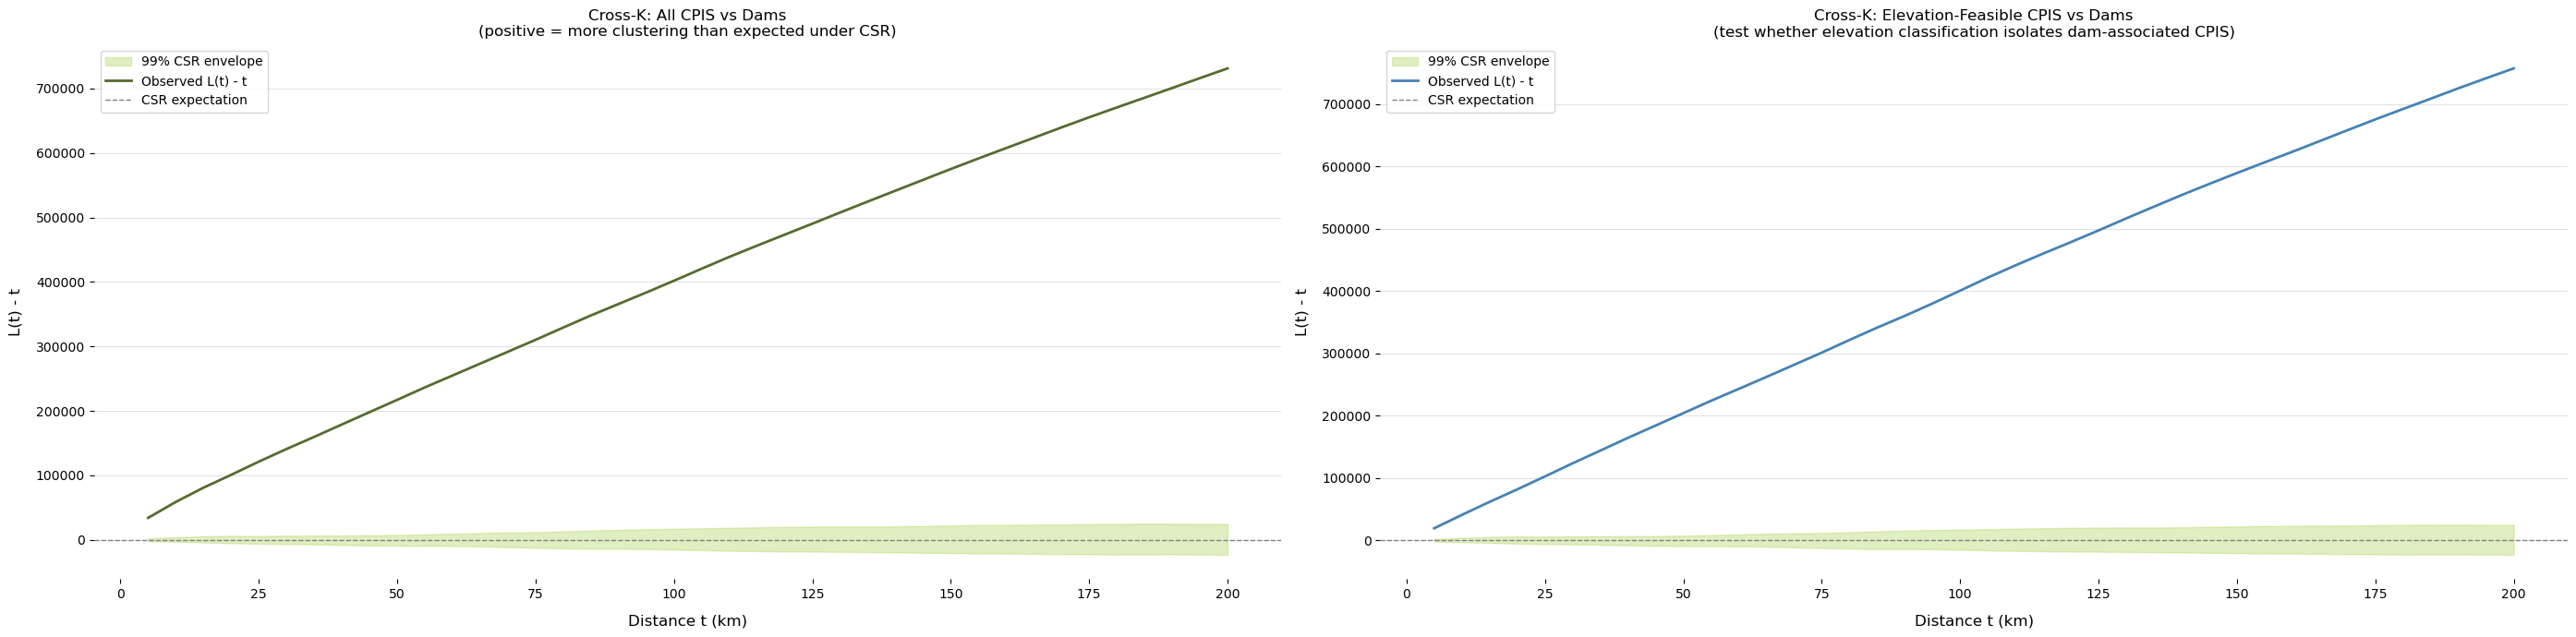

In [21]:
t_km = t_values / 1000
n_panels = 2 if HAS_ELEVATION else 1
fig, axes = plt.subplots(1, n_panels, figsize=(14 * n_panels, 7))
if n_panels == 1:
    axes = [axes]

def _plot_lk(ax, t_km, l_vals, l_lo, l_hi, title, color='darkolivegreen'):
    ax.fill_between(t_km, l_lo, l_hi, alpha=0.3, color='yellowgreen', label='99% CSR envelope')
    ax.plot(t_km, l_vals, color=color, lw=2, label='Observed L(t) - t')
    ax.axhline(0, color='gray', lw=1, ls='--', label='CSR expectation')
    ax.set_xlabel('Distance t (km)', fontsize=12, labelpad=10)
    ax.set_ylabel('L(t) - t', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=12)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(True, axis='y', lw=0.5, color='lightgray')
    ax.grid(False, axis='x')
    ax.legend(fontsize=10)

_plot_lk(axes[0], t_km, l_obs, l_lo, l_hi,
         'Cross-K: All CPIS vs Dams\n(positive = more clustering than expected under CSR)')

if HAS_ELEVATION:
    _plot_lk(axes[1], t_km, l_feas, l_lo, l_hi,
             'Cross-K: Elevation-Feasible CPIS vs Dams\n'
             '(test whether elevation classification isolates dam-associated CPIS)',
             color='steelblue')

plt.tight_layout()
plt.savefig(resolve_path(config['5_Figure0']), dpi=150, bbox_inches='tight')
plt.show()

### B. Geographically Weighted Regression (GWR)

GWR fits a local linear regression at each observation point, weighting nearby observations more heavily
using a spatial kernel. This produces spatially varying coefficient estimates and a local R2 surface.

**Setup:**
- Observations: CPIS centroids (subsampled to MAX_GWR_POINTS for tractability)
- Response y: log(distance to nearest dam + 1)
- Predictors X: groundwater productivity, aridity index, elevation (all standardised)
- Bandwidth: adaptive (nearest-neighbour), selected by AICc minimisation

**Interpretation:** A positive local coefficient on groundwater means that, in that region, CPIS with
higher groundwater productivity tend to be *further* from dams - consistent with groundwater dependence.
High local R2 indicates the predictors explain why CPIS are sited far from dams in that region.

> **Note:** Bandwidth selection may take 5-15 minutes depending on hardware.

In [22]:
# Subsample CPIS for GWR
if len(cpis) > MAX_GWR_POINTS:
    cpis_gwr = cpis.sample(MAX_GWR_POINTS, random_state=SEED).copy()
else:
    cpis_gwr = cpis.copy()

# Distance to nearest dam
dist_to_dam, _ = cKDTree(dam_pts).query(
    np.column_stack([cpis_gwr['cx'], cpis_gwr['cy']]), k=1
)
cpis_gwr['log_dist_dam'] = np.log1p(dist_to_dam)

# Sample aridity and elevation rasters at CPIS centroid locations.
# Rasterio requires coordinates in the raster's native CRS.
def _sample_raster(path, gdf, crs=CRS):
    """Sample raster values at GeoDataFrame point locations. Returns float array."""
    with rasterio.open(path) as src:
        pts = gdf.to_crs(src.crs)
        coords = list(zip(pts.geometry.x, pts.geometry.y))
        vals = np.array([v[0] for v in src.sample(coords)], dtype=float)
        if src.nodata is not None:
            vals[vals == src.nodata] = np.nan
    return vals

pts_gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(cpis_gwr['cx'], cpis_gwr['cy']), crs=CRS
)
cpis_gwr['aridity']   = _sample_raster(resolve_path(config['Global_Aridity_Raster_path']),   pts_gdf)
cpis_gwr['elevation'] = _sample_raster(resolve_path(config['Africa_Elevation_Reprojected_tif_path']), pts_gdf)

# Attach groundwater if available. Prefer direct source-map values from notebook 5;
# GP values are exploratory and older GP-only CSVs may be stale/constant.
if HAS_GP:
    gw_col = 'source_gw_productivity' if 'source_gw_productivity' in gp_df.columns else 'gp_gw_productivity'
    if gp_df[gw_col].nunique(dropna=True) <= 1:
        print('Groundwater values are constant/stale; GWR will use aridity + elevation only.')
        feature_cols = ['aridity', 'elevation']
    else:
        shared = cpis_gwr.index.intersection(gp_df.index)
        cpis_gwr['gw_prod'] = gp_df[gw_col].median()  # default fill
        if len(shared) > 0:
            cpis_gwr.loc[shared, 'gw_prod'] = gp_df.loc[shared, gw_col].values
        feature_cols = ['gw_prod', 'aridity', 'elevation']
else:
    feature_cols = ['aridity', 'elevation']

cpis_gwr = cpis_gwr.dropna(subset=feature_cols + ['log_dist_dam'])
print(f'GWR observations after dropping NaN: {len(cpis_gwr):,}')
print(f'Predictor columns: {feature_cols}')

GWR observations after dropping NaN: 2,000
Predictor columns: ['gw_prod', 'aridity', 'elevation']


In [23]:
# Build GWR arrays
X_raw  = cpis_gwr[feature_cols].values.astype(float)
y_arr  = cpis_gwr['log_dist_dam'].values.reshape(-1, 1).astype(float)
coords = list(zip(cpis_gwr['cx'].values, cpis_gwr['cy'].values))

# Standardise predictors (required for meaningful bandwidth comparison across features)
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0)
X_std[X_std == 0] = 1
X_norm = (X_raw - X_mean) / X_std

# Adaptive bandwidth selection (nearest-neighbour count, minimise AICc)
print(f'Selecting adaptive GWR bandwidth for {len(coords)} observations...')
print('(This may take 5-15 minutes.)')
try:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        bw = Sel_BW(coords, y_arr, X_norm).search(criterion='AICc')
    print(f'AICc-optimal bandwidth: {int(bw)} nearest neighbours')
except Exception as e:
    bw = max(50, int(len(coords) * 0.1))
    print(f'Bandwidth selection failed ({e}). Using fallback: {bw} neighbours.')

gwr_res = GWR(coords, y_arr, X_norm, bw).fit()
print(gwr_res.summary())

# Save results
gwr_out = cpis_gwr[['cx', 'cy', 'log_dist_dam']].copy()
gwr_out['localR2'] = gwr_res.localR2
for i, col in enumerate(feature_cols):
    gwr_out[f'coef_{col}'] = gwr_res.params[:, i + 1]  # params[:,0] is intercept
gwr_out.to_csv(resolve_path(config['CPIS_GWR_Results_csv_path']))
print(f'Saved: {config["CPIS_GWR_Results_csv_path"]}')

Selecting adaptive GWR bandwidth for 2000 observations...
(This may take 5-15 minutes.)
Bandwidth selection failed (Matrix is singular.). Using fallback: 200 neighbours.
Model type                                                         Gaussian
Number of observations:                                                2000
Number of covariates:                                                     4

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                           1969.456
Log-likelihood:                                                   -2822.487
AIC:                                                               5652.975
AICc:                                                              5655.005
BIC:                                                             -13201.945
R2:                                                                   0.191
Adj. R2:                                   

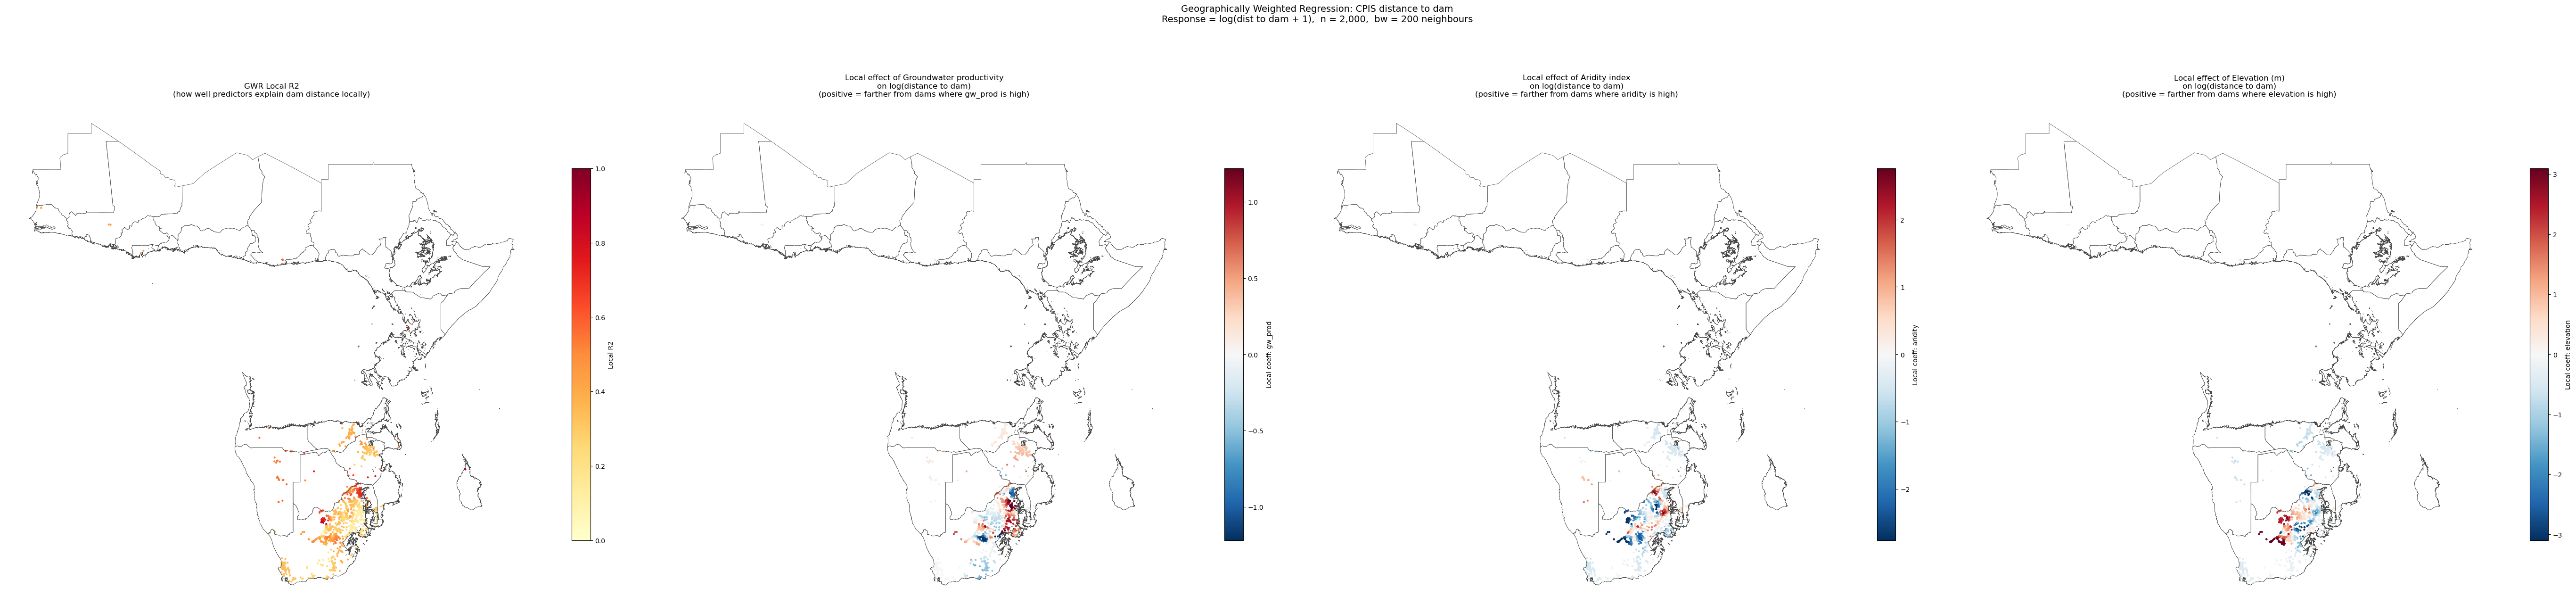

In [24]:
n_feats = len(feature_cols)
fig, axes = plt.subplots(1, n_feats + 1, figsize=(14 * (n_feats + 1), 14))

# Local R2
sc = axes[0].scatter(gwr_out['cx'], gwr_out['cy'],
                     c=gwr_out['localR2'], cmap='YlOrRd', s=4, vmin=0, vmax=1)
ssa_bdry.plot(ax=axes[0], facecolor='none', edgecolor='#444444', lw=0.5)
plt.colorbar(sc, ax=axes[0], label='Local R2', shrink=0.6)
axes[0].set_title('GWR Local R2\n(how well predictors explain dam distance locally)', fontsize=12)
axes[0].set_axis_off()

# Coefficient maps
labels = {
    'gw_prod':   'Groundwater productivity',
    'aridity':   'Aridity index',
    'elevation': 'Elevation (m)',
}
for i, col in enumerate(feature_cols):
    coef = gwr_out[f'coef_{col}'].values
    vmax = np.nanpercentile(np.abs(coef), 95)
    sc = axes[i + 1].scatter(gwr_out['cx'], gwr_out['cy'],
                              c=coef, cmap='RdBu_r', s=4, vmin=-vmax, vmax=vmax)
    ssa_bdry.plot(ax=axes[i + 1], facecolor='none', edgecolor='#444444', lw=0.5)
    plt.colorbar(sc, ax=axes[i + 1], label=f'Local coeff: {col}', shrink=0.6)
    axes[i + 1].set_title(
        f'Local effect of {labels.get(col, col)}\non log(distance to dam)\n'
        f'(positive = farther from dams where {col} is high)',
        fontsize=12,
    )
    axes[i + 1].set_axis_off()

plt.suptitle('Geographically Weighted Regression: CPIS distance to dam\n'
             f'Response = log(dist to dam + 1),  n = {len(gwr_out):,},  bw = {int(bw)} neighbours',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(resolve_path(config['5_Figure2']), dpi=150, bbox_inches='tight')
plt.show()

### C. Flow path connectivity

Notebook 4 classifies each CPIS as *elevation-feasible* if it is within 50 km of a dam **and** at lower
elevation. This is a necessary but not sufficient condition for gravity-fed water delivery - the water must
also have a continuous downslope path along the drainage network.

This section traces a D8 path downstream from the nearest dam for each elevation-feasible CPIS and checks whether the path reaches the CPIS cell within `FLOW_MAX_STEPS` steps. This is a strict natural-drainage check: canal routing, diversions, pumps, and command-area engineering can break this assumption.
CPIS whose nearest-dam flow path does not reach the CPIS cell are reclassified as *elevation-feasible but flow-disconnected*.

> **Runtime note:** Flow tracing is a Python loop over CPIS. At `MAX_FLOW_POINTS` CPIS this typically runs
> in a few minutes. Set `MAX_FLOW_POINTS` to an integer or reduce `FLOW_MAX_STEPS` to speed up.

In [25]:
S = DEM_SUBSAMPLE
print(f'Loading DEM directly at {S}x coarser resolution...')
with rasterio.open(resolve_path(config['Africa_Elevation_Reprojected_tif_path'])) as src:
    out_h = max(1, int(np.ceil(src.height / S)))
    out_w = max(1, int(np.ceil(src.width / S)))
    dem_sub = src.read(
        1,
        out_shape=(out_h, out_w),
        resampling=Resampling.average,
        masked=True,
    )
    scale_x = src.width / out_w
    scale_y = src.height / out_h
    sub_transform = Affine(
        src.transform.a * scale_x, src.transform.b, src.transform.c,
        src.transform.d, src.transform.e * scale_y, src.transform.f,
    )
    dem_crs = src.crs

dem_np = dem_sub.filled(-9999.0).astype(np.float32)
dem_np = np.where(np.isfinite(dem_np), dem_np, -9999.0).astype(np.float32)
flow_cell_m = float((abs(sub_transform.a) + abs(sub_transform.e)) / 2)

print('Computing D8 steepest-descent flow direction...')
valid = dem_np != -9999.0
nrows, ncols = dem_np.shape
flow_dir_arr = np.zeros((nrows, ncols), dtype=np.uint8)
best_slope = np.zeros((nrows, ncols), dtype=np.float32)

# D8 direction encoding: 1=NE, 2=E, 3=SE, 4=S, 5=SW, 6=W, 7=NW, 8=N.
# Direction is assigned to the neighbouring cell with the steepest positive drop.
d8_specs = [
    (1, -1,  1, np.sqrt(2)), (2,  0,  1, 1.0), (3,  1,  1, np.sqrt(2)),
    (4,  1,  0, 1.0),        (5,  1, -1, np.sqrt(2)), (6,  0, -1, 1.0),
    (7, -1, -1, np.sqrt(2)), (8, -1,  0, 1.0),
]

for code, dr, dc, dist_cells in d8_specs:
    rs = slice(max(0, -dr), nrows - max(0, dr))
    cs = slice(max(0, -dc), ncols - max(0, dc))
    rn = slice(max(0,  dr), nrows - max(0, -dr))
    cn = slice(max(0,  dc), ncols - max(0, -dc))

    slope = (dem_np[rs, cs] - dem_np[rn, cn]) / (flow_cell_m * dist_cells)
    mask = valid[rs, cs] & valid[rn, cn] & (slope > best_slope[rs, cs]) & (slope > 0)

    best_view = best_slope[rs, cs]
    dir_view = flow_dir_arr[rs, cs]
    best_view[mask] = slope[mask]
    dir_view[mask] = code

print(f'DEM shape (read at {S}x coarser resolution): {flow_dir_arr.shape}  |  cell size: {flow_cell_m:.1f} m  |  unique D8 values: {np.unique(flow_dir_arr)}')

Loading DEM directly at 16x coarser resolution...
Computing D8 steepest-descent flow direction...
DEM shape (read at 16x coarser resolution): (4796, 5042)  |  cell size: 1522.0 m  |  unique D8 values: [0 1 2 3 4 5 6 7 8]


In [26]:
# D8 direction encoding (values 1-8, 0 = flat/nodata):
# 1=NE  2=E  3=SE  4=S  5=SW  6=W  7=NW  8=N
# (row increases downward, col increases rightward)
D8 = {
    1: (-1,  1), 2: (0,  1), 3: (1,  1),
    4: ( 1,  0),
    5: ( 1, -1), 6: (0, -1), 7: (-1, -1),
    8: (-1,  0),
}

# Use elevation-feasible CPIS if available. Falling back to all CPIS is allowed,
# but it is clearly labelled because it changes the interpretation.
if HAS_ELEVATION:
    feasible = cpis_elev[cpis_elev[ELEV_CLASS_COL].astype(str).str.lower().eq('feasible')].copy()
    flow_population_label = 'elevation-feasible CPIS'
else:
    feasible = cpis.copy()
    flow_population_label = 'all CPIS (no elevation classification available)'

n_available = len(feasible)
sampled_flow = MAX_FLOW_POINTS is not None and n_available > MAX_FLOW_POINTS
if sampled_flow:
    feasible = feasible.sample(MAX_FLOW_POINTS, random_state=SEED).copy()
    print(f'Flow tracing sampled {len(feasible):,} of {n_available:,} {flow_population_label}.')
else:
    print(f'Flow tracing all {n_available:,} {flow_population_label}.')

# Reproject to DEM CRS for pixel-coordinate lookups
feasible_d = feasible.to_crs(dem_crs)
dams_d     = dams.to_crs(dem_crs)

# Match each feasible CPIS to its nearest dam in DEM coordinates.
dam_xy = np.column_stack([dams_d.geometry.x, dams_d.geometry.y])
cpis_xy = np.column_stack([feasible_d.geometry.centroid.x, feasible_d.geometry.centroid.y])
nearest_dist_m, nearest_dam_idx = cKDTree(dam_xy).query(cpis_xy, k=1)
print(f'Matched feasible CPIS to nearest dams: {len(nearest_dam_idx):,}')

def _cell_neighborhood(r, c, radius=2):
    cells = set()
    r, c = int(r), int(c)
    for dr in range(-radius, radius + 1):
        for dc in range(-radius, radius + 1):
            rr, cc = r + dr, c + dc
            if 0 <= rr < nrows and 0 <= cc < ncols:
                cells.add((rr, cc))
    return cells

def _trace_to_target(r0, c0, target_cells):
    r, c = int(r0), int(c0)
    seen = set()
    for step in range(FLOW_MAX_STEPS):
        if (r, c) in target_cells:
            return True, step * flow_cell_m
        if (r, c) in seen:
            return False, np.inf
        seen.add((r, c))
        d = int(flow_dir_arr[r, c])
        if d not in D8:
            return False, np.inf
        dr, dc = D8[d]
        r, c = r + dr, c + dc
        if not (0 <= r < nrows and 0 <= c < ncols):
            return False, np.inf
    return False, np.inf

print(f'Tracing nearest-dam downstream paths for {len(feasible_d):,} CPIS...')
connected, flow_dist_m = [], []
for i, (_, row) in enumerate(feasible_d.iterrows()):
    try:
        dam_geom = dams_d.geometry.iloc[int(nearest_dam_idx[i])]
        rd0, cd0 = rowcol(sub_transform, dam_geom.x, dam_geom.y)
        rt, ct = rowcol(sub_transform, row.geometry.centroid.x, row.geometry.centroid.y)
        if (0 <= int(rd0) < nrows and 0 <= int(cd0) < ncols and
            0 <= int(rt) < nrows and 0 <= int(ct) < ncols):
            target_cells = _cell_neighborhood(rt, ct, radius=2)
            conn, fd = _trace_to_target(rd0, cd0, target_cells)
        else:
            conn, fd = False, np.inf
    except Exception:
        conn, fd = False, np.inf
    connected.append(conn)
    flow_dist_m.append(fd)

feasible = feasible.copy()
feasible['flow_conn'] = connected
feasible['flow_dist'] = flow_dist_m

n = len(feasible)
n_conn = sum(connected)
sample_label = 'sample' if sampled_flow else 'all'
print(f'\nFlow-traced population ({sample_label}): {n:,} of {n_available:,} {flow_population_label}')
print(f'Nearest-dam flow path reaches CPIS: {n_conn:,}  ({100*n_conn/n:.1f}%)')
print(f'Not flow-connected:               {n-n_conn:,}  ({100*(n-n_conn)/n:.1f}%)')

Flow tracing all 10,460 elevation-feasible CPIS.
Matched feasible CPIS to nearest dams: 10,460
Tracing nearest-dam downstream paths for 10,460 CPIS...

Flow-traced population (all): 10,460 of 10,460 elevation-feasible CPIS
Nearest-dam flow path reaches CPIS: 2,243  (21.4%)
Not flow-connected:               8,217  (78.6%)


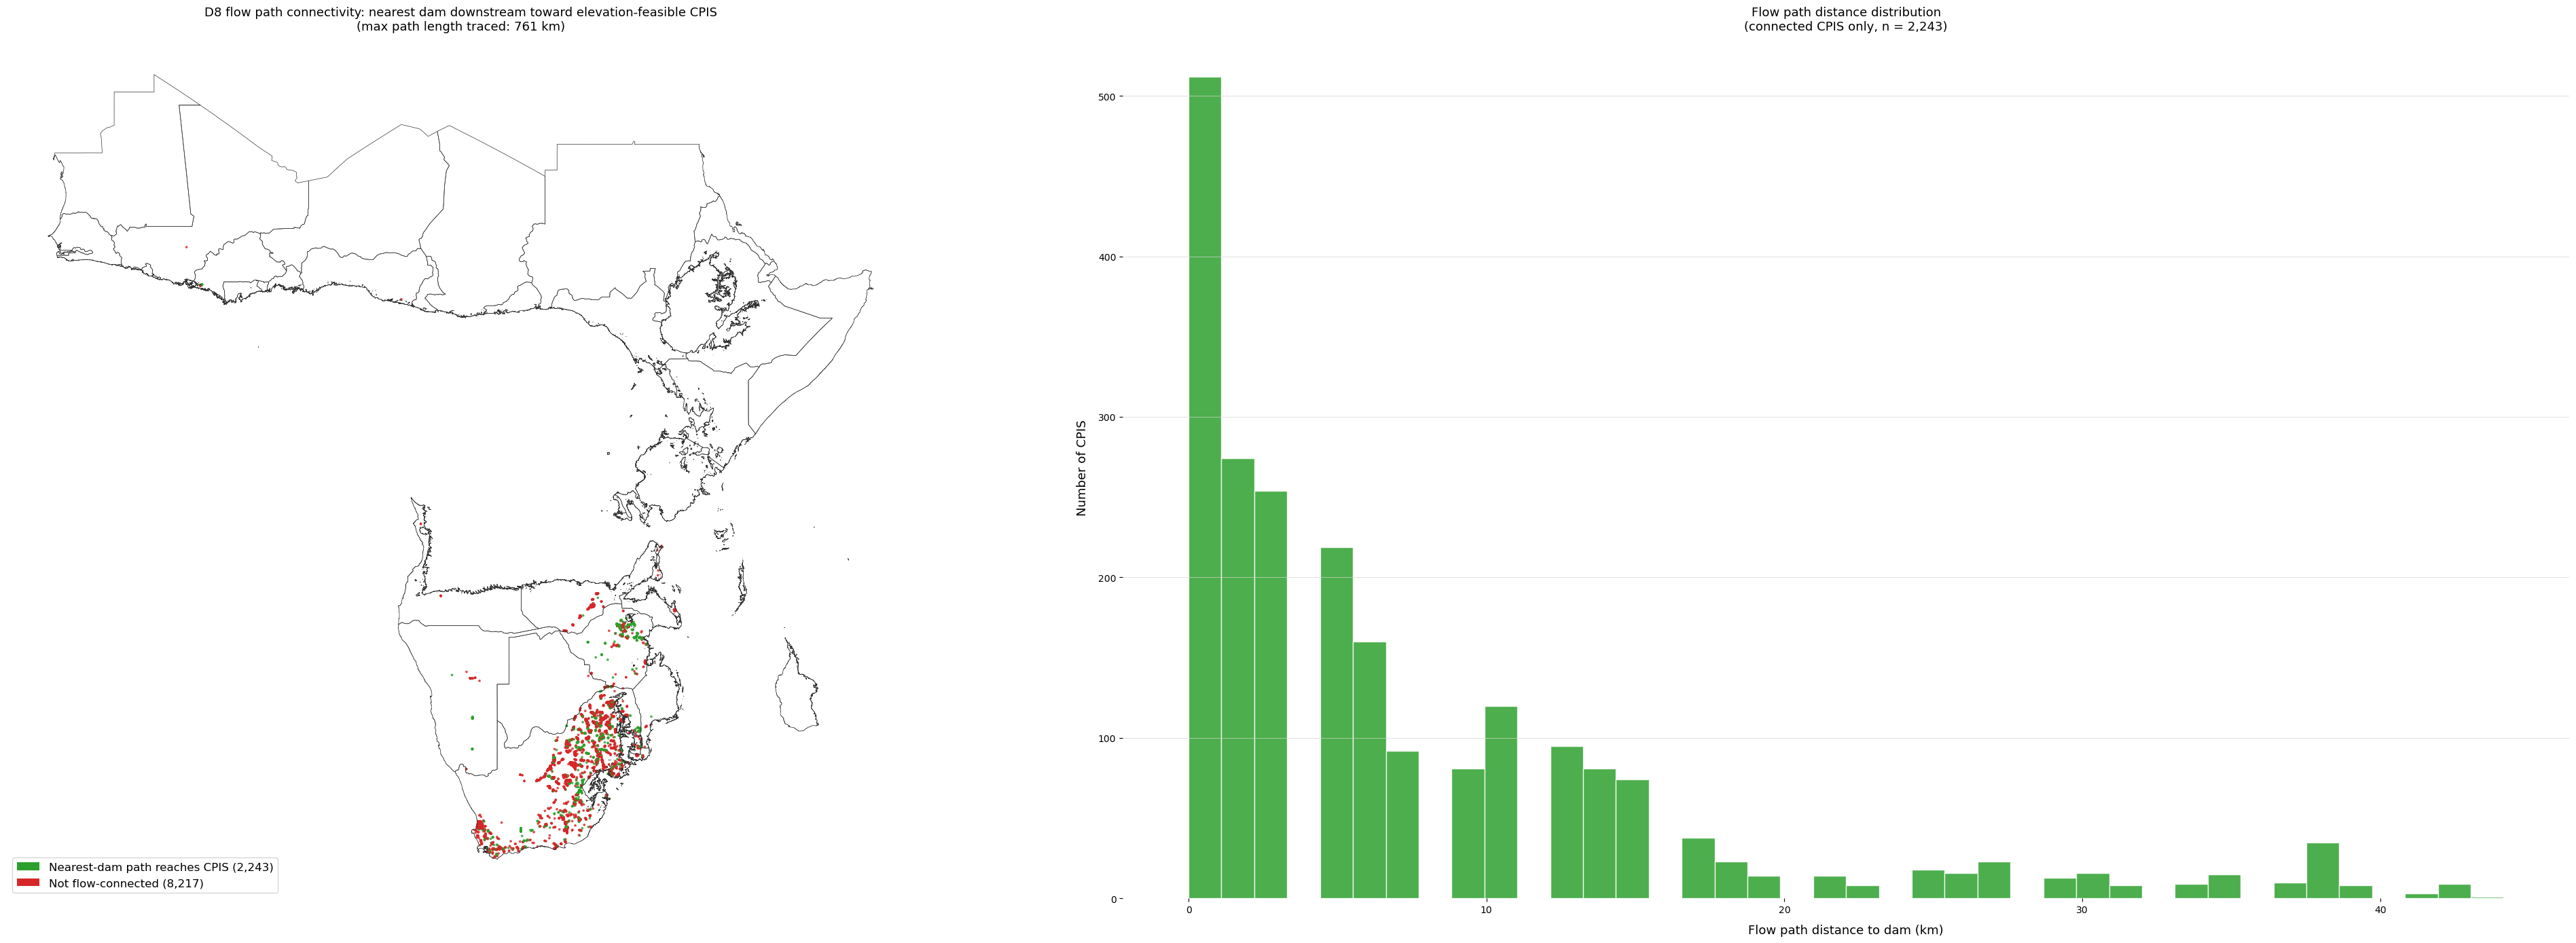

C:\Users\ermil\AppData\Local\Temp\ipykernel_52196\2378866651.py:49: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  out_gdf.to_file(out_path)


Saved: Data/Processed/CPIS_Flow_Connectivity-shp/CPIS_Flow_Connectivity.shp


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(42, 14))

# Left panel: map of nearest-dam flow path reaching CPIS vs not
colors = ['#2ca02c' if c else '#d62728' for c in feasible['flow_conn']]
feas_centroids = feasible.copy()
feas_centroids.geometry = feasible.geometry.centroid
feas_centroids.plot(ax=axes[0], color=colors, markersize=3, alpha=0.7)
ssa_bdry.plot(ax=axes[0], facecolor='none', edgecolor='#333333', lw=0.5)
# dams.plot(ax=axes[0], color='steelblue', markersize=6, alpha=0.5, label='Dams')
legend_els = [
    Patch(facecolor='#2ca02c', label=f'Nearest-dam path reaches CPIS ({n_conn:,})'),
    Patch(facecolor='#d62728', label=f'Not flow-connected ({n-n_conn:,})'),
]
axes[0].legend(handles=legend_els, fontsize=12, loc='lower left')
max_km = FLOW_MAX_STEPS * flow_cell_m / 1000
axes[0].set_title(
    f'D8 flow path connectivity: nearest dam downstream toward elevation-feasible CPIS\n'
    f'(max path length traced: {max_km:.0f} km)',
    fontsize=13,
)
axes[0].set_axis_off()

# Right panel: distribution of flow path distances (connected CPIS only)
connected_km = [d / 1000 for c, d in zip(connected, flow_dist_m) if c and np.isfinite(d)]
if connected_km:
    axes[1].hist(connected_km, bins=40, color='#2ca02c', edgecolor='white', alpha=0.85)
    axes[1].set_xlabel('Flow path distance to dam (km)', fontsize=13, labelpad=10)
    axes[1].set_ylabel('Number of CPIS', fontsize=13, labelpad=10)
    axes[1].set_title(
        f'Flow path distance distribution\n(connected CPIS only, n = {len(connected_km):,})',
        fontsize=13,
    )
    for spine in axes[1].spines.values():
        spine.set_visible(False)
    axes[1].grid(True, axis='y', lw=0.5, color='lightgray')

plt.tight_layout()
plt.savefig(resolve_path(config['5_Figure3']), dpi=150, bbox_inches='tight')
plt.show()

# Save shapefile of connectivity-classified CPIS
out_path = resolve_path(config['CPIS_Flow_Connectivity_shp_path'])
os.makedirs(os.path.dirname(out_path), exist_ok=True)
out_gdf = gpd.GeoDataFrame(
    {'flow_conn': feasible['flow_conn'], 'flow_dist_m': feasible['flow_dist']},
    geometry=feasible.geometry.centroid,
    crs=feasible.crs,
)
out_gdf.to_file(out_path)
print(f'Saved: {config["CPIS_Flow_Connectivity_shp_path"]}')